# Deepfake Model Evaluation Notebook
This notebook evaluates your trained ResNet-50 deepfake model on a folder-based test dataset.

In [2]:
# Install missing packages
%pip install torch torchvision scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os

In [4]:
# Configuration
WORK_DIR = r"E:/deepfake-detection-final/"  # Change to your directory
TEST_DIR = r"E:/image dataset zip/Dataset/Test"    # Path to your test dataset
MODEL_PATH = os.path.join(WORK_DIR, "best_model_image.pth")
IMG_SIZE = 224
BATCH_SIZE = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUT_SIZE = 2  # Number of classes: real/fake

In [5]:
class WrapModel(nn.Module):
    def __init__(self, model):
        super(WrapModel, self).__init__()
        self.model = model

    def forward(self, x):
        return self.model(x)
    

In [6]:
import torch
import torch.nn as nn
from torchvision.models import resnet50

In [7]:
model = WrapModel(resnet50(weights=None))
num_ftrs = model.model.fc.in_features
model.model.fc = nn.Linear(num_ftrs, OUT_SIZE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()

# Label mapping
index_label = {0: "FAKE", 1: "REAL"}

In [8]:
# Preprocessing transform
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [9]:
# Evaluation function
def evaluate_test_dataset(test_dir, batch_size=BATCH_SIZE):
    test_dataset = datasets.ImageFolder(test_dir, transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            preds = torch.argmax(torch.softmax(outputs, dim=1), dim=1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=test_dataset.classes)
    cm = confusion_matrix(y_true, y_pred)

    return accuracy, report, cm

In [15]:
# Run evaluation
accuracy, report, cm = evaluate_test_dataset(TEST_DIR)

print(f"Test Accuracy: {accuracy*100:.2f}%")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(cm)

KeyboardInterrupt: 

In [14]:
# Plot Loss per batch
plt.figure(figsize=(10,5))
plt.plot(batch_losses, marker='o')
plt.title("Test Loss per Batch")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Optional: Plot overall accuracy as a single bar
plt.figure(figsize=(5,5))
plt.bar(["Test Accuracy"], [accuracy*100], color='teal')
plt.ylim(0,100)
plt.ylabel("Accuracy (%)")
plt.title("Test Accuracy")
plt.show()


NameError: name 'batch_losses' is not defined

<Figure size 1000x500 with 0 Axes>

Test Accuracy: 90.04%

Classification Report:
              precision    recall  f1-score   support

        Fake       0.85      0.98      0.91      5492
        Real       0.98      0.82      0.89      5413

    accuracy                           0.90     10905
   macro avg       0.91      0.90      0.90     10905
weighted avg       0.91      0.90      0.90     10905


Confusion Matrix:
[[5380  112]
 [ 974 4439]]


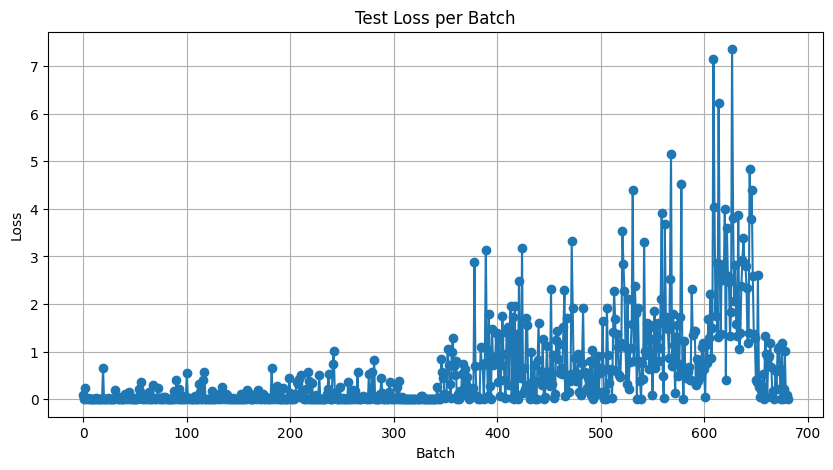

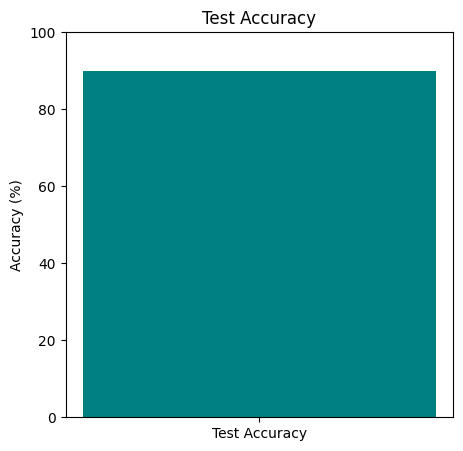

In [16]:
import matplotlib.pyplot as plt
import torch.nn as nn

# Loss function
criterion = nn.CrossEntropyLoss()

def evaluate_test_dataset_with_loss(test_dir, batch_size=BATCH_SIZE):
    test_dataset = datasets.ImageFolder(test_dir, transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    y_true = []
    y_pred = []
    batch_losses = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            batch_losses.append(loss.item())
            
            preds = torch.argmax(torch.softmax(outputs, dim=1), dim=1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=test_dataset.classes)
    cm = confusion_matrix(y_true, y_pred)

    return accuracy, report, cm, batch_losses

# Run evaluation
accuracy, report, cm, batch_losses = evaluate_test_dataset_with_loss(TEST_DIR)

print(f"Test Accuracy: {accuracy*100:.2f}%")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(cm)

# Plot Loss per batch
plt.figure(figsize=(10,5))
plt.plot(batch_losses, marker='o')
plt.title("Test Loss per Batch")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Optional: Plot overall accuracy as a single bar
plt.figure(figsize=(5,5))
plt.bar(["Test Accuracy"], [accuracy*100], color='teal')
plt.ylim(0,100)
plt.ylabel("Accuracy (%)")
plt.title("Test Accuracy")
plt.show()


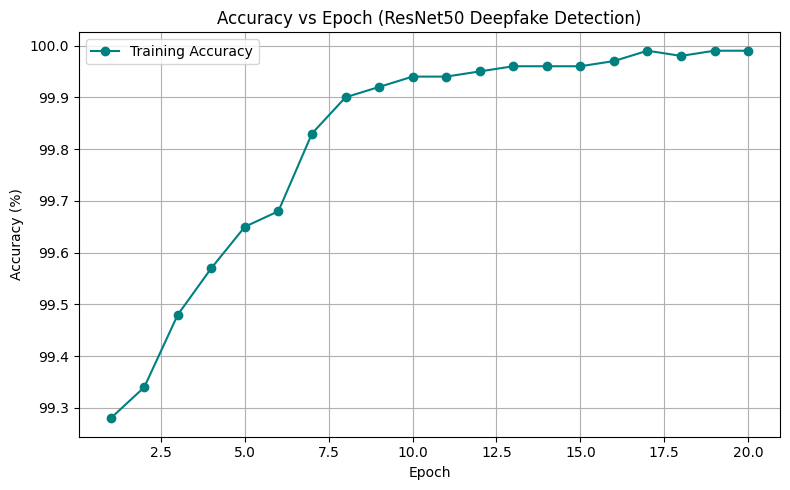

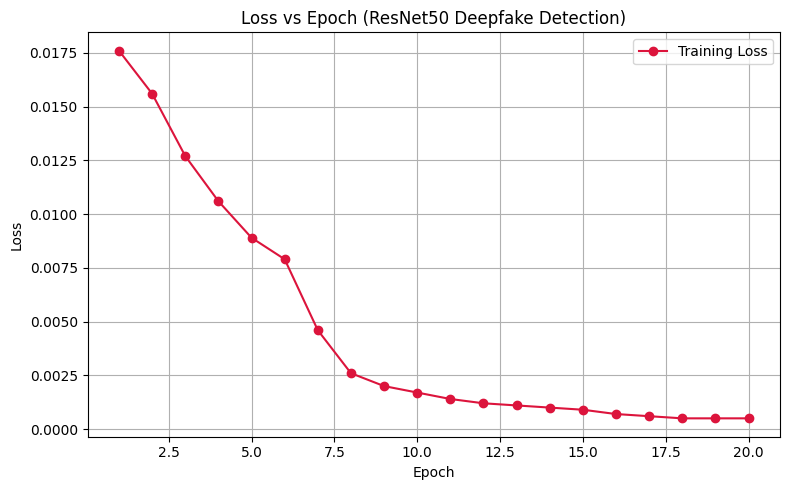

In [12]:
import matplotlib.pyplot as plt

# Data from your training logs
epochs = list(range(1, 21))
train_loss = [0.0176, 0.0156, 0.0127, 0.0106, 0.0089, 0.0079, 0.0046, 0.0026, 0.0020, 0.0017,
              0.0014, 0.0012, 0.0011, 0.0010, 0.0009, 0.0007, 0.0006, 0.0005, 0.0005, 0.0005]
train_acc = [0.9928, 0.9934, 0.9948, 0.9957, 0.9965, 0.9968, 0.9983, 0.9990, 0.9992, 0.9994,
             0.9994, 0.9995, 0.9996, 0.9996, 0.9996, 0.9997, 0.9999, 0.9998, 0.9999, 0.9999]
val_acc = [0.9856, 0.9777, 0.9871, 0.9869, 0.9882, 0.9856, 0.9879, 0.9882, 0.9879, 0.9881,
           0.9879, 0.9881, 0.9881, 0.9881, 0.9882, 0.9876, 0.9879, 0.9882, 0.9882, 0.9879]

# Convert accuracies to percentages
train_acc = [a * 100 for a in train_acc]
val_acc = [a * 100 for a in val_acc]

# ----------------------------
# Plot Accuracy vs Epoch
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, marker='o', label='Training Accuracy', color='teal')

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs Epoch (ResNet50 Deepfake Detection)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ----------------------------
# Plot Loss vs Epoch
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, marker='o', label='Training Loss', color='crimson')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch (ResNet50 Deepfake Detection)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
